In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# CELDA 1: SET UP E IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from shot_dna.data import load_all_games, load_season_aggregate
from shot_dna.eda import profile_table, effect_size_table
from shot_dna.viz import (
    plot_box_by_category,
    plot_binned_mean,
    plot_calibration,
    plot_shot_chart,
    plot_hex_quality,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Tabla Shots

In [ ]:
# CARGAR LA TABLA CENTRAL: shots
shots_raw = load_all_games("shots")
print("Filas x columnas:", shots_raw.shape)
shots_raw.info()

Filas x columnas: (1459, 41)
<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1459 non-null   str    
 1   gameId            1459 non-null   int64  
 2   season            1459 non-null   str    
 3   period            1459 non-null   int64  
 4   chanceId          1459 non-null   str    
 5   possessionId      1459 non-null   str    
 6   startFrame        1459 non-null   int64  
 7   startWallClock    1459 non-null   int64  
 8   startGameClock    1459 non-null   float64
 9   endFrame          1459 non-null   int64  
 10  endWallClock      1459 non-null   int64  
 11  endGameClock      1459 non-null   float64
 12  location          1433 non-null   object 
 13  region            1433 non-null   str    
 14  shotClock         1452 non-null   float64
 15  shooterId         1459 non-null   int64  
 16  offTeamId         1459 n

In [5]:
# S.0: LIMPIEZA Y VARIABLES DERIVADAS

# Excluimos los 26 tiros sin puntuación del modelo (sin location, tipo ni contest).
shots = shots_raw.dropna(subset=["shotQuality"]).copy()

# Eliminamos la columna duplicada que agrega nuestro loader.
shots = shots.drop(columns="game_id")

# Booleanos con nulos: de object a boolean (admite NA).
for col in ["catchAndShoot", "contested"]:
    shots[col] = shots[col].astype("boolean")

# Separamos la ubicación [x, y] en dos columnas (en pies).
shots[["x", "y"]] = pd.DataFrame(shots["location"].tolist(), index=shots.index)

# Revisamos releaseTime antes de recortarlo.
print("Tiros con releaseTime > 24 s:", (shots["releaseTime"] > 24).sum())
shots["releaseTime_capped"] = shots["releaseTime"].clip(upper=24)

# Etiquetas legibles y valor del tiro.
shots["shot_value"] = np.where(shots["three"], "Triple", "Doble")
shots["points_value"] = np.where(shots["three"], 3, 2)

# Orden lógico del nivel de contest: de más abierto a más defendido.
CONTEST_ORDER = ["open", "light", "average", "plus", "blocked"]
shots["contestLevel"] = pd.Categorical(
    shots["contestLevel"], categories=CONTEST_ORDER, ordered=True
)

print("Tiros analizables:", len(shots))

Tiros con releaseTime > 24 s: 1
Tiros analizables: 1433


### S.1 Variable objetivo: shotQuality

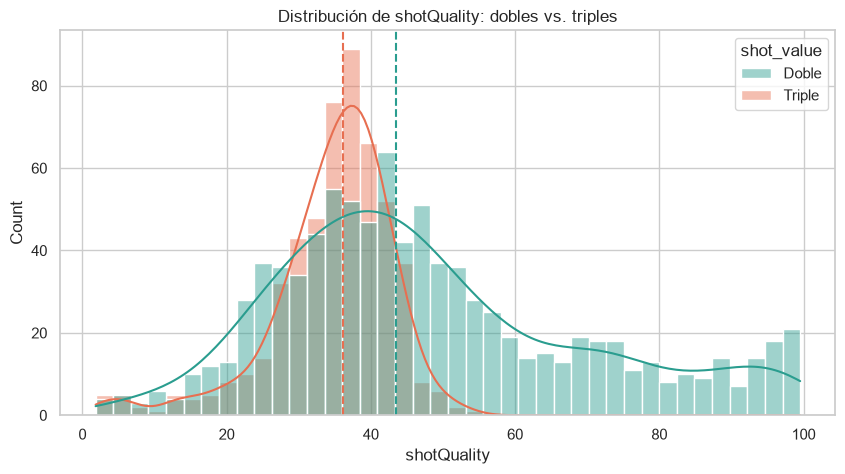

            count       mean        std       min        25%        50%  \
shot_value                                                                
Doble       914.0  48.052021  21.628115  2.605962  33.057036  43.487999   
Triple      519.0  34.678071   8.364105  1.826712  31.045517  36.093491   

                  75%        max  
shot_value                        
Doble       59.651585  99.528030  
Triple      40.001774  53.436207  
Asimetría: 1.07


In [6]:
# S.1.a Distribucion, dobles vs triples

# S.1.a: DISTRIBUCIÓN DE shotQuality
colors = {"Doble": "#2a9d8f", "Triple": "#e76f51"}

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=shots, x="shotQuality", hue="shot_value", bins=40,
    kde=True, palette=colors, alpha=0.45, ax=ax,
)

# Línea de mediana por tipo de tiro.
for label, color in colors.items():
    median = shots.loc[shots["shot_value"] == label, "shotQuality"].median()
    ax.axvline(median, color=color, linestyle="--", linewidth=1.5)

ax.set_title("Distribución de shotQuality: dobles vs. triples")
plt.show()

print(shots.groupby("shot_value")["shotQuality"].describe())
print("Asimetría:", round(shots["shotQuality"].skew(), 2))

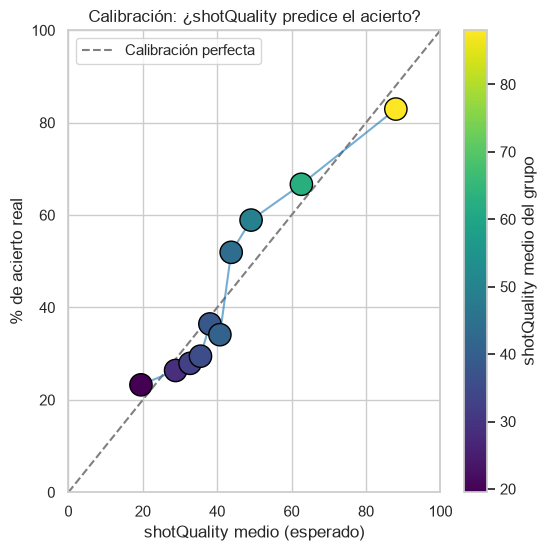

,expected,actual,n
bin,,,
"(1.826, 26.029]",19.505244,23.255814,129
"(26.029, 31.043]",28.816172,26.356589,129
"(31.043, 34.18]",32.705484,27.906977,129
"(34.18, 36.765]",35.509191,29.457364,129
"(36.765, 39.384]",38.036010,36.434109,129
"(39.384, 42.114]",40.726753,34.108527,129
"(42.114, 45.802]",43.763604,51.937984,129
"(45.802, 53.737]",49.107513,58.914729,129
"(53.737, 73.101]",62.634605,66.666667,129


In [7]:
# S.1.b: CALIBRACIÓN DEL TARGET CONTRA EL RESULTADO REAL
no_foul = shots[~shots["fouled"]]
ax, calibration = plot_calibration(no_foul)
plt.show()
calibration

[complexShotType] excluidas por n < 20: {'postFadeaway': 16, 'lob': 11, 'shakeAndRaise': 10, 'heave': 9, 'leaner': 3}


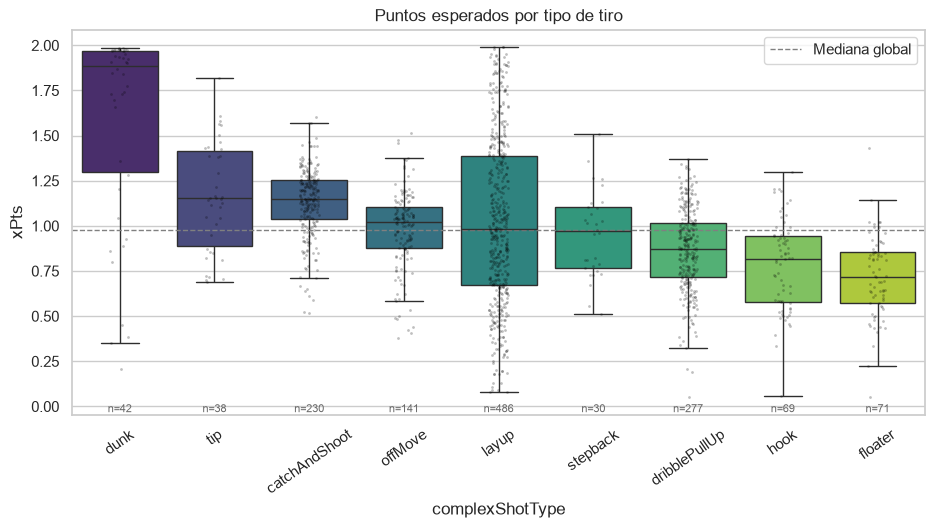

In [8]:
# S.1.c: PUNTOS ESPERADOS POR TIRO
shots["xPts"] = shots["shotQuality"] / 100 * shots["points_value"]

plot_box_by_category(
    shots, "complexShotType", target="xPts", palette="viridis",
    title="Puntos esperados por tipo de tiro",
)
plt.show()

### S.2 Grupo Movimiento

[complexShotType] excluidas por n < 20: {'postFadeaway': 16, 'lob': 11, 'shakeAndRaise': 10, 'heave': 9, 'leaner': 3}


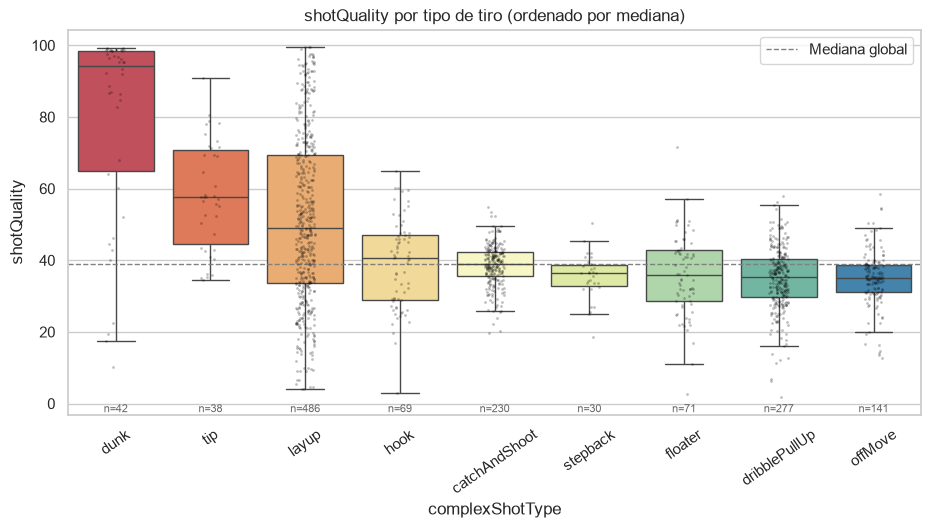

In [9]:
# S.2.a: shotQuality POR TIPO DE TIRO DETALLADO
plot_box_by_category(
    shots, "complexShotType", palette="Spectral",
    title="shotQuality por tipo de tiro (ordenado por mediana)",
)
plt.show()

[shotType] excluidas por n < 20: {'heave': 9}


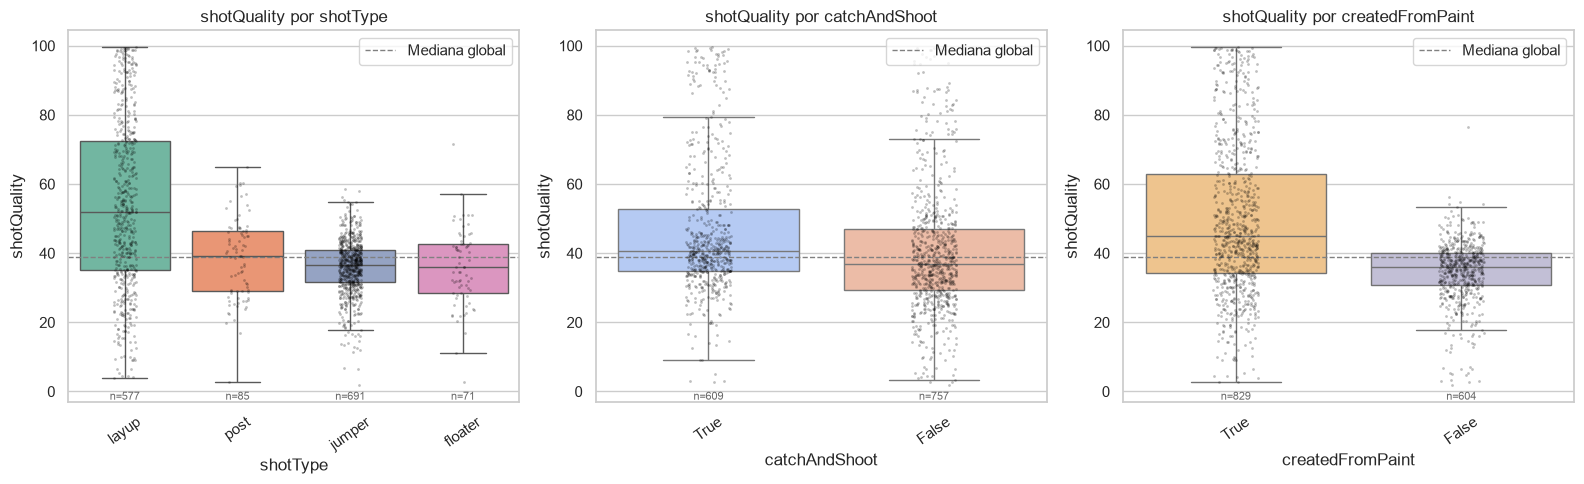

In [10]:
# S.2.b: VARIABLES DE MOVIMIENTO BINARIAS O SIMPLES
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_box_by_category(shots, "shotType", palette="Set2", ax=axes[0])
plot_box_by_category(shots, "catchAndShoot", palette="coolwarm", ax=axes[1])
plot_box_by_category(shots, "createdFromPaint", palette="PuOr", ax=axes[2])
plt.tight_layout()
plt.show()

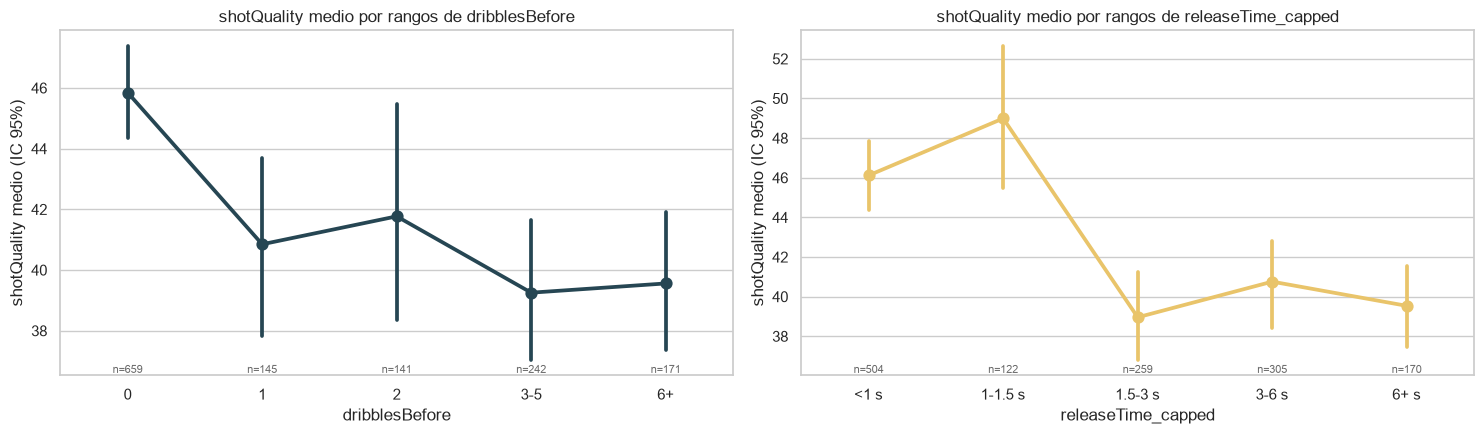

In [11]:
# S.2.c: BOTES PREVIOS Y TIEMPO DE LANZAMIENTO
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_binned_mean(
    shots, "dribblesBefore", bins=[-0.5, 0.5, 1.5, 2.5, 5.5, 30],
    labels=["0", "1", "2", "3-5", "6+"], color="#264653", ax=axes[0],
)
plot_binned_mean(
    shots, "releaseTime_capped", bins=[0, 1, 1.5, 3, 6, 24],
    labels=["<1 s", "1-1.5 s", "1.5-3 s", "3-6 s", "6+ s"],
    color="#e9c46a", ax=axes[1],
)
plt.tight_layout()
plt.show()

### S.3 Grupo Presión defensiva

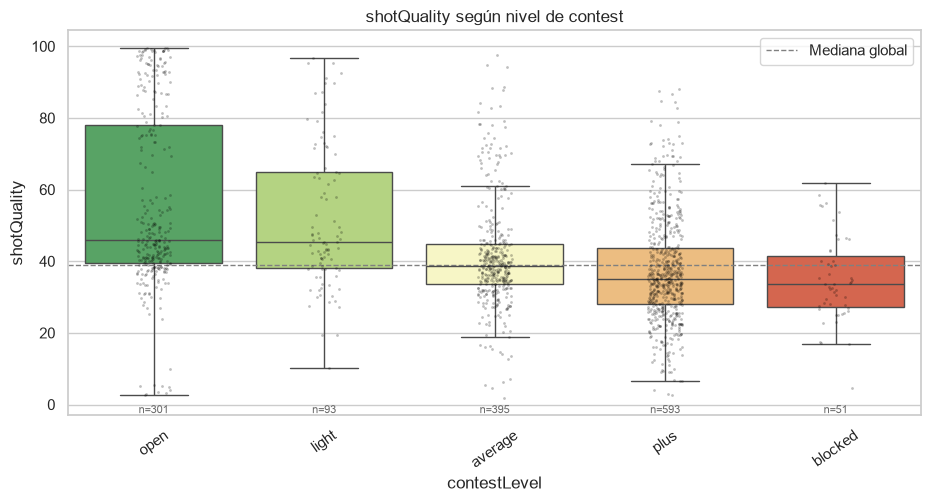

In [12]:
# S.3.a: NIVEL DE CONTEST, EN ORDEN LÓGICO (verde = abierto, rojo = defendido)
plot_box_by_category(
    shots, "contestLevel", order=CONTEST_ORDER, palette="RdYlGn_r",
    title="shotQuality según nivel de contest",
)
plt.show()

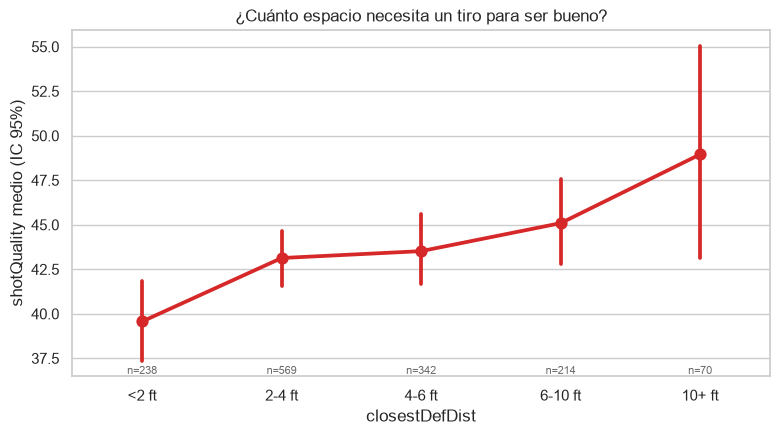

In [13]:
# S.3.b: DISTANCIA AL DEFENSOR MÁS CERCANO
plot_binned_mean(
    shots, "closestDefDist", bins=[0, 2, 4, 6, 10, 40],
    labels=["<2 ft", "2-4 ft", "4-6 ft", "6-10 ft", "10+ ft"],
    color="#d62828",
    title="¿Cuánto espacio necesita un tiro para ser bueno?",
)
plt.show()

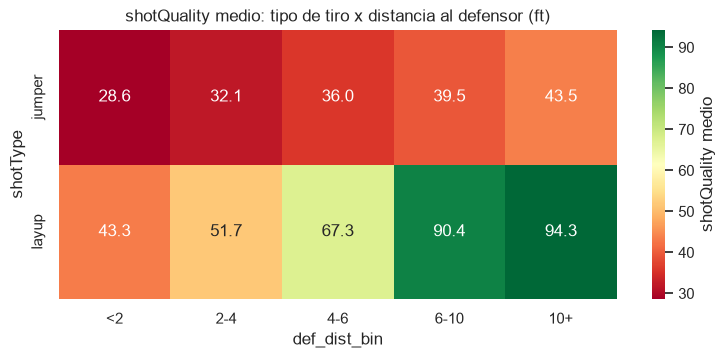

Tamaño de muestra por celda:


def_dist_bin,<2,2-4,4-6,6-10,10+
shotType,,,,,
jumper,36,187,232,186,50
layup,160,301,80,23,13


In [14]:
# S.3.c: MAPA DE CALOR distancia al defensor x tipo de tiro
shots["def_dist_bin"] = pd.cut(
    shots["closestDefDist"], bins=[0, 2, 4, 6, 10, 40],
    labels=["<2", "2-4", "4-6", "6-10", "10+"],
)
subset = shots[shots["shotType"].isin(["jumper", "layup"])]

mean_table = subset.pivot_table(
    index="shotType", columns="def_dist_bin", values="shotQuality",
    aggfunc="mean", observed=True,
)
count_table = subset.pivot_table(
    index="shotType", columns="def_dist_bin", values="shotQuality",
    aggfunc="size", observed=True,
)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(mean_table, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
            cbar_kws={"label": "shotQuality medio"})
ax.set_title("shotQuality medio: tipo de tiro x distancia al defensor (ft)")
plt.show()

print("Tamaño de muestra por celda:")
count_table

### S.4 Grupo Ubicación y spacing

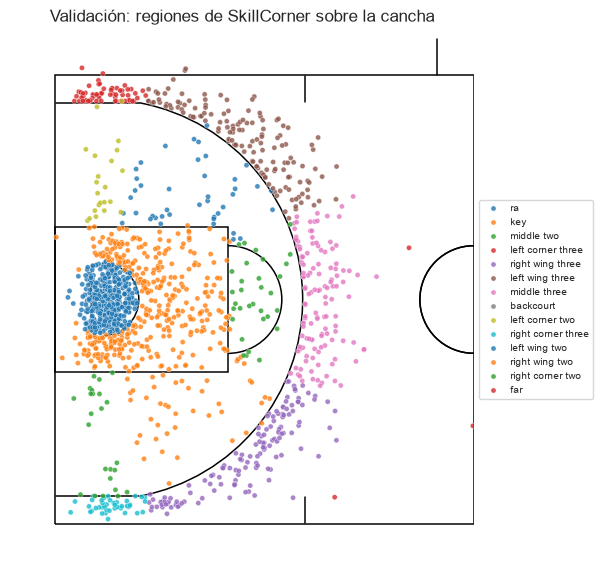

In [15]:
# S.4.a: VALIDACIÓN VISUAL DE COORDENADAS POR REGIÓN
fig, ax = plt.subplots(figsize=(8, 7))
plot_shot_chart(shots, color_col="region", categorical=True, ax=ax,
                title="Validación: regiones de SkillCorner sobre la cancha")
plt.show()

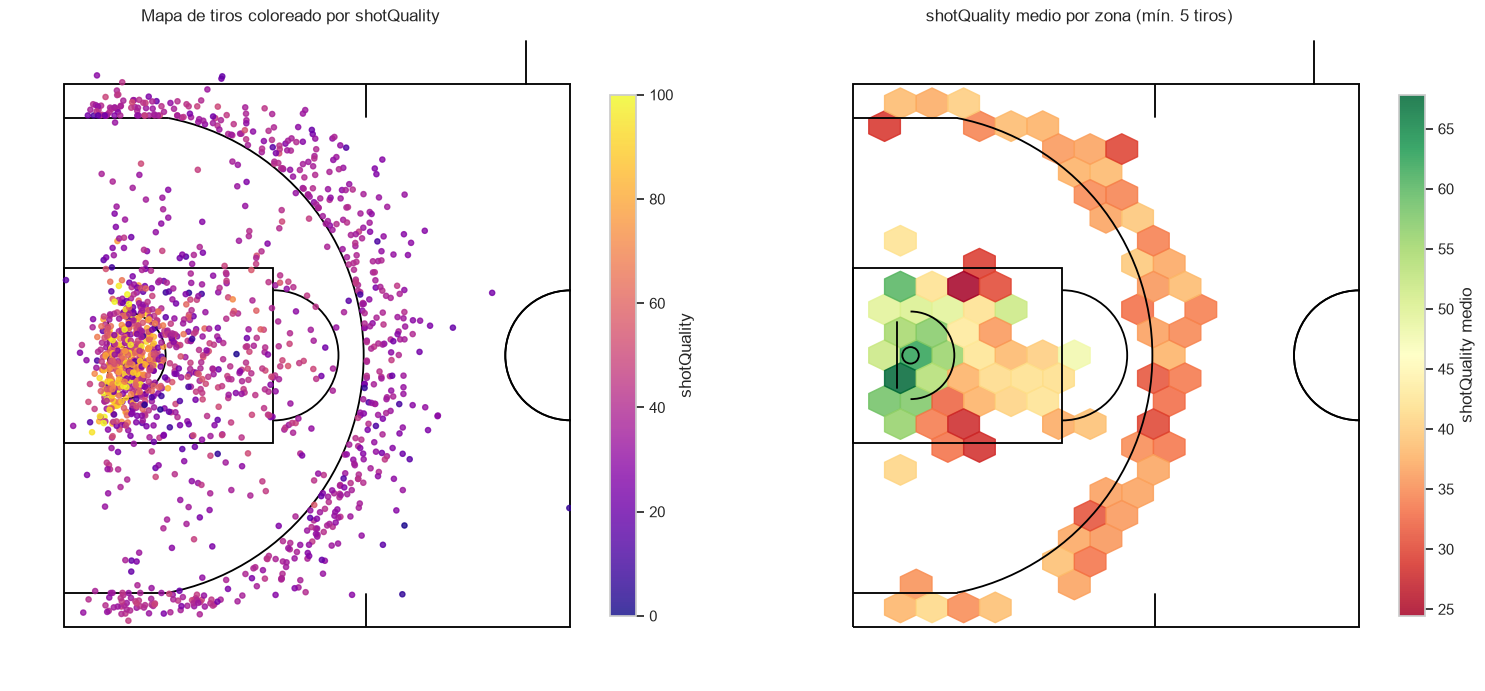

In [16]:
# S.4.b: MAPAS DE TIRO — CADA TIRO Y CALIDAD MEDIA POR ZONA
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_shot_chart(shots, color_col="shotQuality", cmap="plasma", ax=axes[0])
plot_hex_quality(shots, mincnt=5, ax=axes[1])
plt.tight_layout()
plt.savefig("../reports/figures/shot_quality_map.png", dpi=200, bbox_inches="tight")
plt.show()

[region] excluidas por n < 20: {'backcourt': 9, 'far': 3}


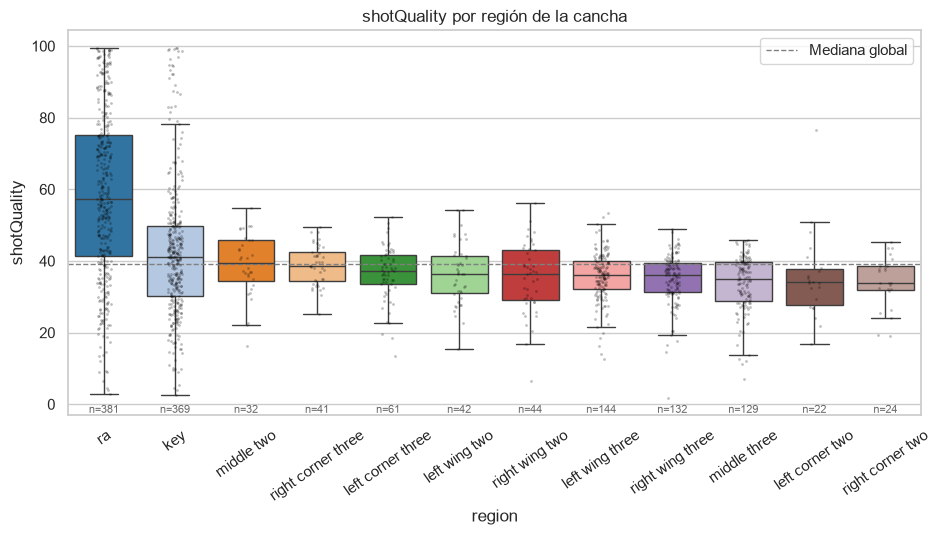

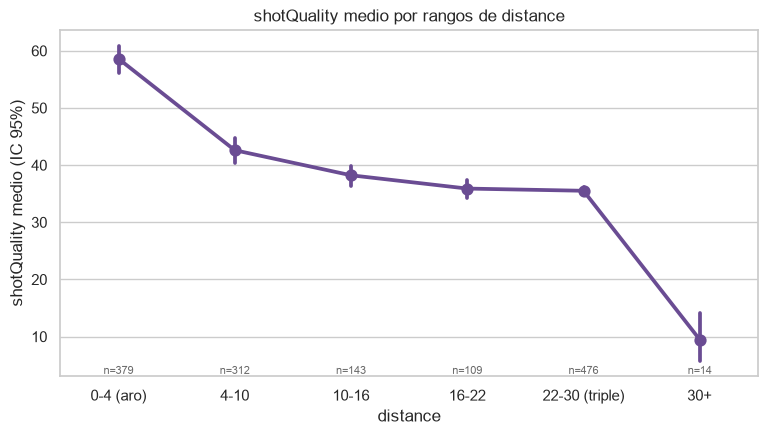

In [17]:
# S.4.c: REGIÓN Y DISTANCIA AL ARO
plot_box_by_category(shots, "region", palette="tab20",
                     title="shotQuality por región de la cancha")
plt.show()

# 22.15 ft = 6.75 m, la línea de triple FIBA.
plot_binned_mean(
    shots, "distance", bins=[0, 4, 10, 16, 22.15, 30, 70],
    labels=["0-4 (aro)", "4-10", "10-16", "16-22", "22-30 (triple)", "30+"],
    color="#6a4c93",
)
plt.show()

### S.5 Grupo Contexto de juego

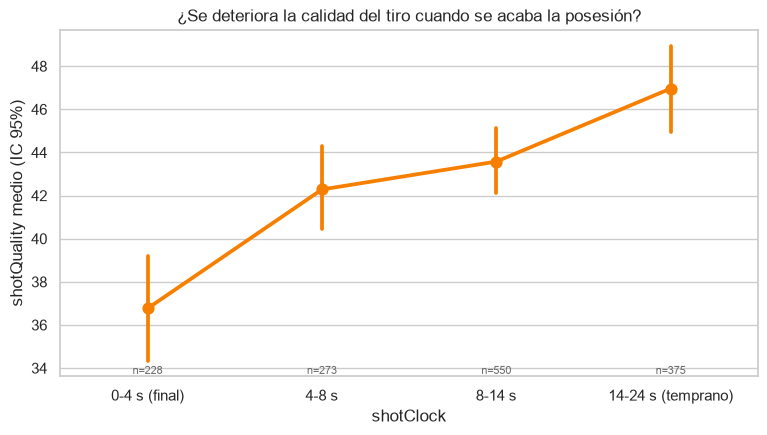

In [18]:
# S.5.a: RELOJ DE POSESIÓN
plot_binned_mean(
    shots, "shotClock", bins=[-0.1, 4, 8, 14, 24.1],
    labels=["0-4 s (final)", "4-8 s", "8-14 s", "14-24 s (temprano)"],
    color="#f77f00",
    title="¿Se deteriora la calidad del tiro cuando se acaba la posesión?",
)
plt.show()

[period] excluidas por n < 20: {5: 19}


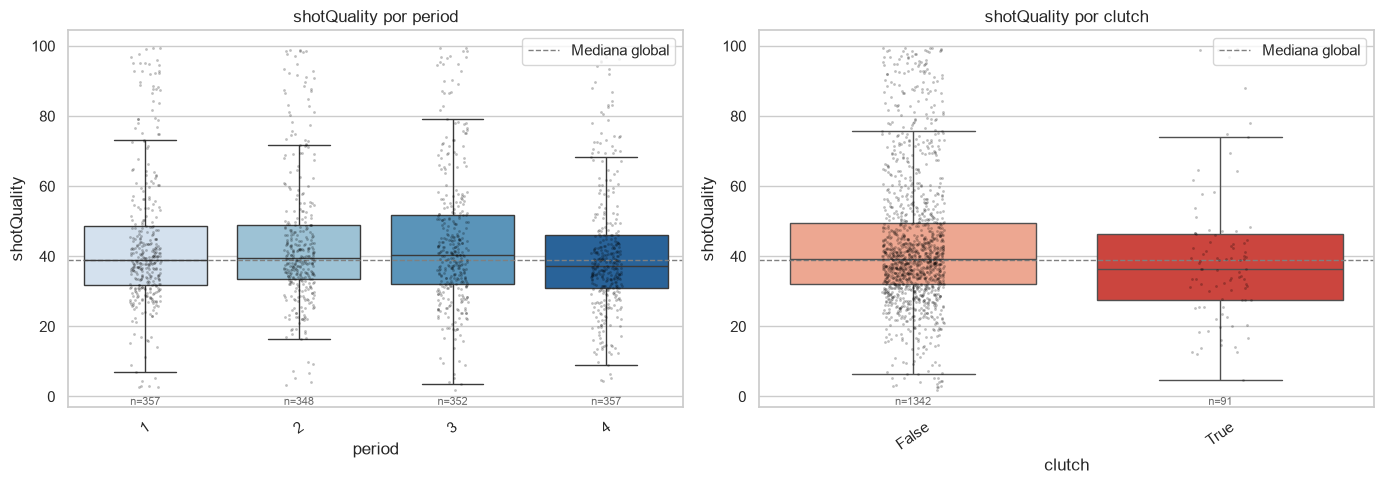

In [19]:
# S.5.b: PERIODO Y MOMENTOS DECISIVOS
# period 5 = prórroga. "Clutch" = últimos 2 minutos del 4.º cuarto o prórroga.
shots["clutch"] = (shots["period"] >= 4) & (shots["startGameClock"] <= 120)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_box_by_category(shots, "period", order=[1, 2, 3, 4, 5],
                     palette="Blues", ax=axes[0])
plot_box_by_category(shots, "clutch", palette="Reds", ax=axes[1])
plt.tight_layout()
plt.show()

### S.6 Grupo Creación

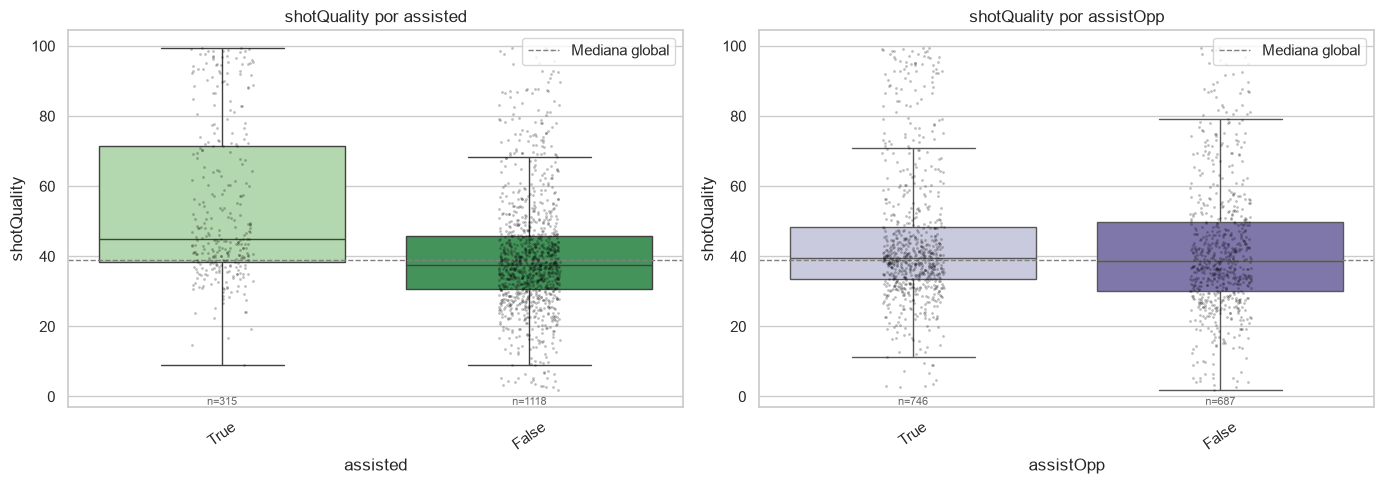

,n,shotQuality_media,pct_acierto
assisted,,,
False,991,40.6,26.8
True,299,54.8,100.0


In [20]:
# S.6: ASISTENCIA Y OPORTUNIDAD DE ASISTENCIA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_box_by_category(shots, "assisted", palette="Greens", ax=axes[0])
plot_box_by_category(shots, "assistOpp", palette="Purples", ax=axes[1])
plt.tight_layout()
plt.show()

# Calidad vs. resultado: ¿los tiros asistidos son mejores o solo entran más?
shots[~shots["fouled"]].groupby("assisted").agg(
    n=("id", "size"),
    shotQuality_media=("shotQuality", "mean"),
    pct_acierto=("outcome", lambda s: 100 * s.mean()),
).round(1)

### S.7 Ranking: ¿qué variables mueven más shotQuality?

In [21]:
# S.7: FUERZA DE ASOCIACIÓN DE CADA VARIABLE CON EL TARGET
ranking = effect_size_table(
    shots,
    target="shotQuality",
    numeric_cols=["distance", "closestDefDist", "dribblesBefore",
                  "releaseTime_capped", "shotClock", "startGameClock"],
    categorical_cols=["complexShotType", "shotType", "contestLevel", "region",
                      "catchAndShoot", "createdFromPaint", "assisted",
                      "assistOpp", "three", "period", "clutch"],
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=ranking, y="variable", x="fuerza", hue="tipo",
            palette={"numérica": "#457b9d", "categórica": "#e63946"}, ax=ax)
ax.set_title("% de la variación de shotQuality asociado a cada variable")
ax.set_xlabel("Fuerza (ρ² o η²)")
plt.show()

ranking.round(3)

ModuleNotFoundError: No module named 'scipy'

### S.8 Insight nuevo: talento vs. calidad del tiro

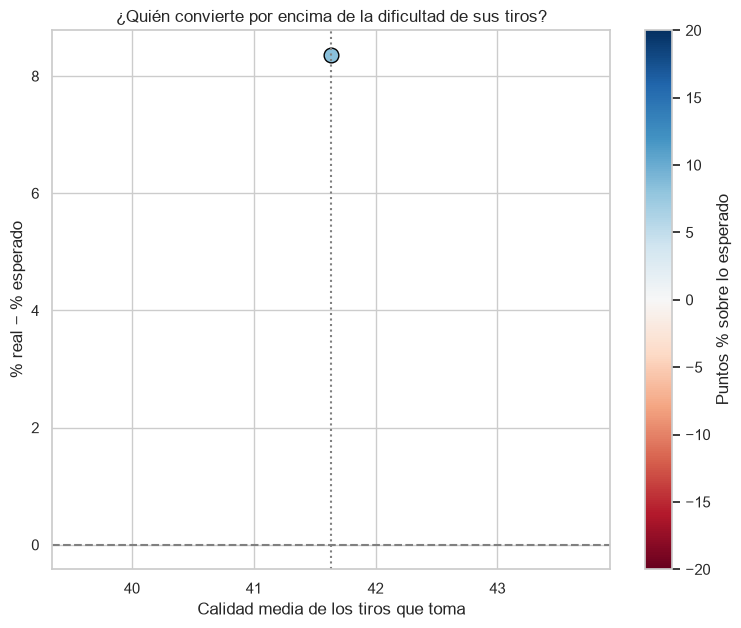

,n,calidad_media,pct_real,shot_making
shooterId,,,,
58474,28,41.6,50.0,8.4


In [22]:
# S.8: SHOT-MAKING POR JUGADOR (mín. 25 tiros sin falta)
players = (
    shots[~shots["fouled"]]
    .groupby("shooterId")
    .agg(n=("id", "size"),
         calidad_media=("shotQuality", "mean"),
         pct_real=("outcome", lambda s: 100 * s.mean()))
)
players = players[players["n"] >= 25].copy()
players["shot_making"] = players["pct_real"] - players["calidad_media"]

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(players["calidad_media"], players["shot_making"],
                     s=players["n"] * 4, c=players["shot_making"],
                     cmap="RdBu", vmin=-20, vmax=20, edgecolor="black")
ax.axhline(0, color="gray", linestyle="--")
ax.axvline(players["calidad_media"].median(), color="gray", linestyle=":")
plt.colorbar(scatter, label="Puntos % sobre lo esperado")
ax.set_xlabel("Calidad media de los tiros que toma")
ax.set_ylabel("% real − % esperado")
ax.set_title("¿Quién convierte por encima de la dificultad de sus tiros?")
plt.show()

players.sort_values("shot_making", ascending=False).round(1)

### S.9 Animación: cómo cambian los tiros mientras corre el reloj de posesión

In [23]:
# S.9: MAPA DE TIROS ANIMADO POR TRAMO DEL RELOJ DE POSESIÓN
anim = shots.dropna(subset=["x", "y", "shotClock"]).copy()
anim["tramo_reloj"] = pd.cut(
    anim["shotClock"], bins=[-0.1, 4, 8, 14, 24.1],
    labels=["0-4 s (final)", "4-8 s", "8-14 s", "14-24 s (temprano)"],
)
# Ordenamos de reloj lleno a reloj agotado para que la animación "corra".
anim = anim.sort_values("shotClock", ascending=False)
anim["tramo_reloj"] = anim["tramo_reloj"].astype(str)

fig = px.scatter(
    anim, x="x", y="y", color="shotQuality", animation_frame="tramo_reloj",
    color_continuous_scale="RdYlGn", range_color=[0, 100],
    range_x=[-47, 0], range_y=[-25, 25],
    hover_data=["complexShotType", "contestLevel", "distance"],
    title="Dónde y con qué calidad se tira según el reloj de posesión",
)

# Líneas básicas de cancha FIBA (en pies): aro, zona y línea de triple.
hoop_x, three_radius, corner_y, baseline_x = -40.76, 22.15, 21.65, -45.93
angle = np.arcsin(corner_y / three_radius)
theta = np.linspace(-angle, angle, 60)
arc_x = hoop_x + three_radius * np.cos(theta)
arc_y = three_radius * np.sin(theta)
arc_path = f"M {baseline_x},{-corner_y} L {arc_x[0]},{arc_y[0]} " + " ".join(
    f"L {x},{y}" for x, y in zip(arc_x[1:], arc_y[1:])
) + f" L {baseline_x},{corner_y}"

fig.update_layout(shapes=[
    dict(type="circle", x0=hoop_x - 0.75, x1=hoop_x + 0.75, y0=-0.75, y1=0.75,
         line=dict(color="orange", width=2)),
    dict(type="rect", x0=baseline_x, x1=-26.9, y0=-8.04, y1=8.04,
         line=dict(color="gray")),
    dict(type="path", path=arc_path, line=dict(color="gray")),
])
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

fig.write_html("../reports/figures/shot_clock_animation.html")

---

In [4]:
# CELDA 3: ESTADISTICAS DESCRIPTIVAS DE LAS COLUMNAS NUMERICAS
shots.describe()

,gameId,period,startFrame,startWallClock,startGameClock,endFrame,endWallClock,endGameClock,shotClock,shooterId,offTeamId,defTeamId,passerId,blockerId,distance,dribblesBefore,shotQuality,releaseTime,closestDefDist,closestDefId,game_id
count,1459.000000,1459.000000,1459.000000,1.459000e+03,1459.000000,1459.000000,1.459000e+03,1459.000000,1452.000000,1459.000000,1459.000000,1459.000000,1280.000000,51.000000,1433.000000,1378.000000,1433.000000,1377.000000,1433.000000,1433.000000,1459.000000
mean,148714.863605,2.532557,67573.685401,2.702947e+06,290.556625,67595.095271,2.703804e+06,289.725347,10.342948,44167.262509,1328.922550,1328.928033,46594.351562,46793.549020,13.194746,2.146589,43.208280,3.045461,4.376369,45626.090021,148714.863605
std,35236.029854,1.147910,43039.563822,1.721583e+06,174.480463,43039.389571,1.721576e+06,174.474164,5.748550,16919.411047,7.254545,7.193077,16193.964727,17929.025211,9.956991,3.327270,19.102161,4.113218,3.148900,17088.617071,35236.029854
min,114086.000000,1.000000,332.000000,1.328000e+04,0.000000,337.000000,1.348000e+04,0.000000,0.000000,446.000000,1315.000000,1315.000000,446.000000,15369.000000,0.183749,0.000000,1.826712,0.000000,0.107332,446.000000,114086.000000
25%,114169.000000,2.000000,29786.000000,1.191440e+06,142.000000,29816.000000,1.192640e+06,141.011253,6.310000,28410.000000,1322.000000,1322.000000,31739.000000,34867.000000,3.825289,0.000000,32.002804,0.880000,2.417086,31457.000000,114169.000000
50%,114243.000000,3.000000,66330.000000,2.653200e+06,291.697998,66335.000000,2.653400e+06,291.093964,10.800000,58474.000000,1330.000000,1331.000000,59099.000000,59096.000000,10.758778,1.000000,39.037746,1.800000,3.621193,59096.000000,114243.000000
75%,184439.000000,4.000000,102123.500000,4.084940e+06,441.838458,102146.000000,4.085840e+06,441.145544,14.320000,59152.000000,1335.000000,1334.000000,59157.000000,59156.500000,22.829130,3.000000,49.208752,4.120000,5.424831,59152.000000,184439.000000
max,191313.000000,5.000000,176057.000000,7.042280e+06,592.362366,176087.000000,7.043480e+06,591.882568,24.000000,94471.000000,1340.000000,1340.000000,63998.000000,94471.000000,67.439502,22.000000,99.528030,79.200000,35.087374,94471.000000,191313.000000


In [5]:
# CELDA 4: CONTEO DE NULOS POR COLUMNA
shots.isnull().sum().sort_values(ascending=False)

blockerId           1408
foulId              1316
passerId             179
releaseTime           82
dribblesBefore        81
touchId               81
catchAndShoot         75
location              26
distance              26
closestDefDist        26
complexShotType       26
shotType              26
region                26
contested             26
contestLevel          26
shotQuality           26
closestDefId          26
shotClock              7
id                     0
startFrame             0
possessionId           0
chanceId               0
period                 0
season                 0
gameId                 0
startGameClock         0
startWallClock         0
outcome                0
assisted               0
assistOpp              0
defTeamId              0
shooterId              0
offTeamId              0
endFrame               0
endGameClock           0
endWallClock           0
fouled                 0
three                  0
blocked                0
createdFromPaint       0


In [6]:
# CELDA 5: DISTRIBUCION DE LAS COLUMNAS CATEGORICAS
for col in ["complexShotType", "contestLevel", "shotType", "catchAndShoot"]:
    print(f"\n--- {col} ---")
    print(shots[col].value_counts(dropna=False))


--- complexShotType ---
complexShotType
layup            486
dribblePullUp    277
catchAndShoot    230
offMove          141
floater           71
hook              69
dunk              42
tip               38
stepback          30
NaN               26
postFadeaway      16
lob               11
shakeAndRaise     10
heave              9
leaner             3
Name: count, dtype: int64

--- contestLevel ---
contestLevel
plus       593
average    395
open       301
light       93
blocked     51
NaN         26
Name: count, dtype: int64

--- shotType ---
shotType
jumper     691
layup      577
post        85
floater     71
NaN         26
heave        9
Name: count, dtype: int64

--- catchAndShoot ---
catchAndShoot
False    769
True     615
None      75
Name: count, dtype: int64


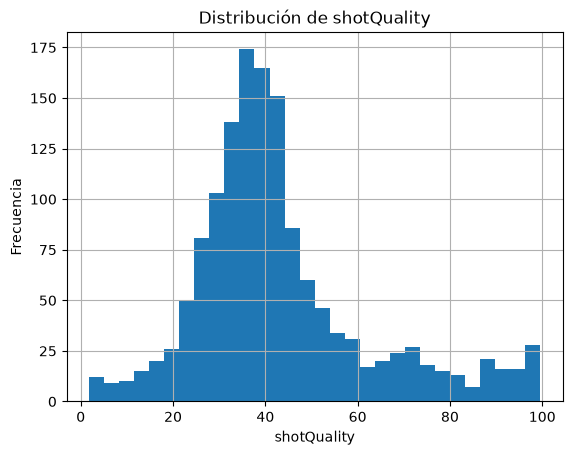

In [7]:
# CELDA 6: HISTOGRAMA DE LA VARIABLE CENTRAL
shots["shotQuality"].hist(bins=30)
plt.title("Distribución de shotQuality")
plt.xlabel("shotQuality")
plt.ylabel("Frecuencia")
plt.show()

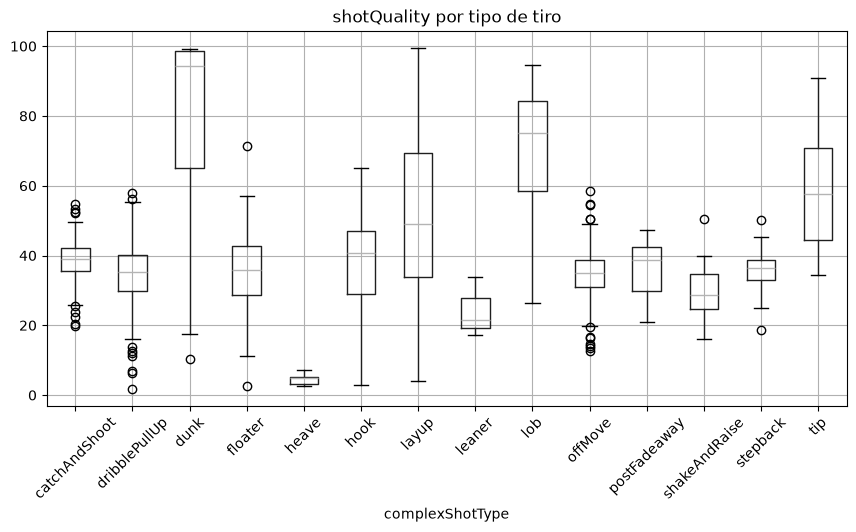

In [8]:
# CELDA 7: PRIMERA MIRADA: shotQuality POR TIPO DE ACCION
shots.boxplot(column="shotQuality", by="complexShotType", figsize=(10, 5), rot=45)
plt.title("shotQuality por tipo de tiro")
plt.suptitle("")  # quita el título automático feo que pone pandas
plt.show()

In [9]:
# CELDA 8: REPETIR EL MISMO CHEQUEO CON LAS OTRAS TABLAS RELEVANTES
for table_name in ["picks", "drives", "closeouts", "chances", "matchups"]:
    df = load_all_games(table_name)
    print(f"\n=== {table_name} ===")
    print("Shape:", df.shape)
    print("Columnas:", list(df.columns))


=== picks ===
Shape: (1520, 27)
Columnas: ['id', 'gameId', 'season', 'chanceId', 'possessionId', 'period', 'gameClock', 'frame', 'wallClock', 'direct', 'location', 'region', 'shotClock', 'ballhandlerId', 'screenerId', 'ballhandlerDefId', 'screenerDefId', 'offTeamId', 'defTeamId', 'locationType', 'bhrDefType', 'scrDefType', 'bhrOutcomes', 'scrOutcomes', 'handoffPick', 'touchId', 'game_id']

=== drives ===
Shape: (660, 29)
Columnas: ['id', 'gameId', 'season', 'chanceId', 'possessionId', 'period', 'startGameClock', 'startFrame', 'startWallClock', 'endGameClock', 'endFrame', 'endWallClock', 'direct', 'location', 'region', 'endLoc', 'shotClock', 'ballhandlerId', 'ballhandlerDefId', 'offTeamId', 'defTeamId', 'category', 'blowby', 'endType', 'direction', 'bhrOutcomes', 'dribbleThrough', 'touchId', 'game_id']

=== closeouts ===
Shape: (601, 32)
Columnas: ['id', 'gameId', 'season', 'chanceId', 'possessionId', 'period', 'touchGameClock', 'touchFrame', 'touchWallClock', 'startGameClock', 'startF